In [ ]:
#DSO Project 3
#Shivi Anand, Edvina Buyuksoy
#Dataset: Tetouan City Power Consumption (Morocco)

In [ ]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [ ]:
# read the data into a df and learn about columns, dtypes, etc.
power_df = pd.read_csv('wind_dataset.csv')
power_df.info()
power_df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6574 entries, 0 to 6573
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   DATE     6574 non-null   object 
 1   WIND     6574 non-null   float64
 2   IND      6574 non-null   int64  
 3   RAIN     6574 non-null   float64
 4   IND.1    6513 non-null   float64
 5   T.MAX    5953 non-null   float64
 6   IND.2    6513 non-null   float64
 7   T.MIN    5900 non-null   float64
 8   T.MIN.G  6214 non-null   float64
dtypes: float64(7), int64(1), object(1)
memory usage: 462.4+ KB


,DATE,WIND,IND,RAIN,IND.1,T.MAX,IND.2,T.MIN,T.MIN.G
0,1961-01-01,13.67,0,0.2,0.0,9.5,0.0,3.7,-1.0
1,1961-01-02,11.50,0,5.1,0.0,7.2,0.0,4.2,1.1
2,1961-01-03,11.25,0,0.4,0.0,5.5,0.0,0.5,-0.5
3,1961-01-04,8.63,0,0.2,0.0,5.6,0.0,0.4,-3.2
4,1961-01-05,11.92,0,10.4,0.0,7.2,1.0,-1.5,-7.5


In [ ]:
# Convert to datetime format and set as index
power_df['DATE'] = pd.to_datetime(power_df['DATE'])
power_df = power_df.set_index('DATE')

# Resample from 10-minute data to daily averages to make the series manageable
daily_avg = power_df.resample('W').mean()

In [ ]:
# Checking if data is stationary -- from class example code
def check_stationarity(series):
    result = adfuller(series.values)
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))
    if (result[1] <= 0.05) & (result[4]['5%'] > result[0]):
        print("\u001b[32mStationary\u001b[0m")
    else:
        print("\x1b[31mNon-stationary\x1b[0m")

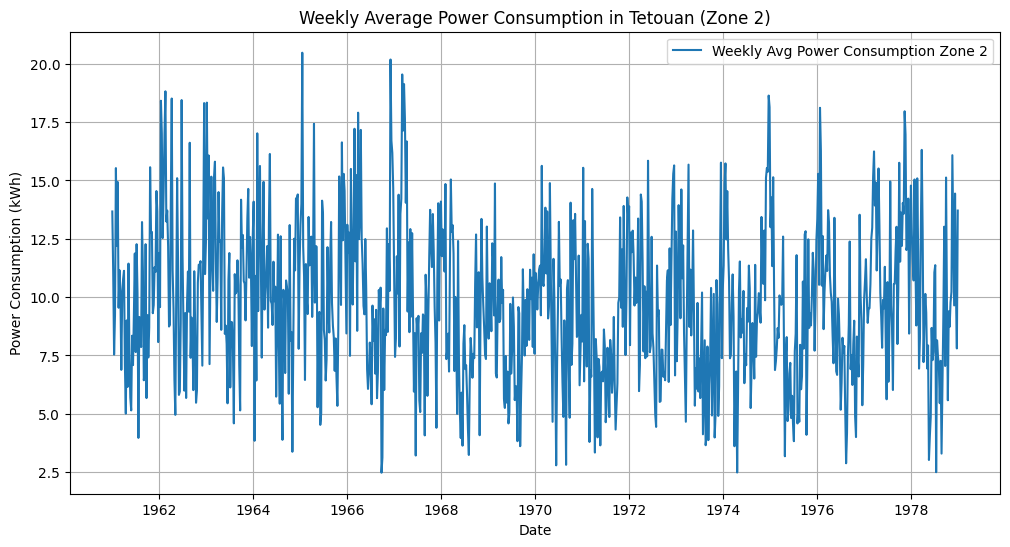

In [ ]:
# original series visualization
plt.figure(figsize=(12, 6))
plt.plot(daily_avg.index, daily_avg['WIND'], label='Weekly Avg Power Consumption Zone 2')
plt.xlabel('Date')
plt.ylabel('Power Consumption (kWh)')
plt.title('Weekly Average Power Consumption in Tetouan (Zone 2)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# running the stationary yes/no function on the data
check_stationarity(daily_avg['WIND'])

ADF Statistic: -7.647215
p-value: 0.000000
Critical Values:
	1%: -3.437
	5%: -2.865
	10%: -2.568
Stationary


In [ ]:
# apply first level differencing
power_df = daily_avg['PowerConsumption_Zone2'].diff().dropna()

#checking stationarity after differencing
print("After First Differencing Stationarity Check")
check_stationarity(power_df)

After First Differencing Stationarity Check
ADF Statistic: -6.423929
p-value: 0.000000
Critical Values:
	1%: -3.566
	5%: -2.920
	10%: -2.598
Stationary


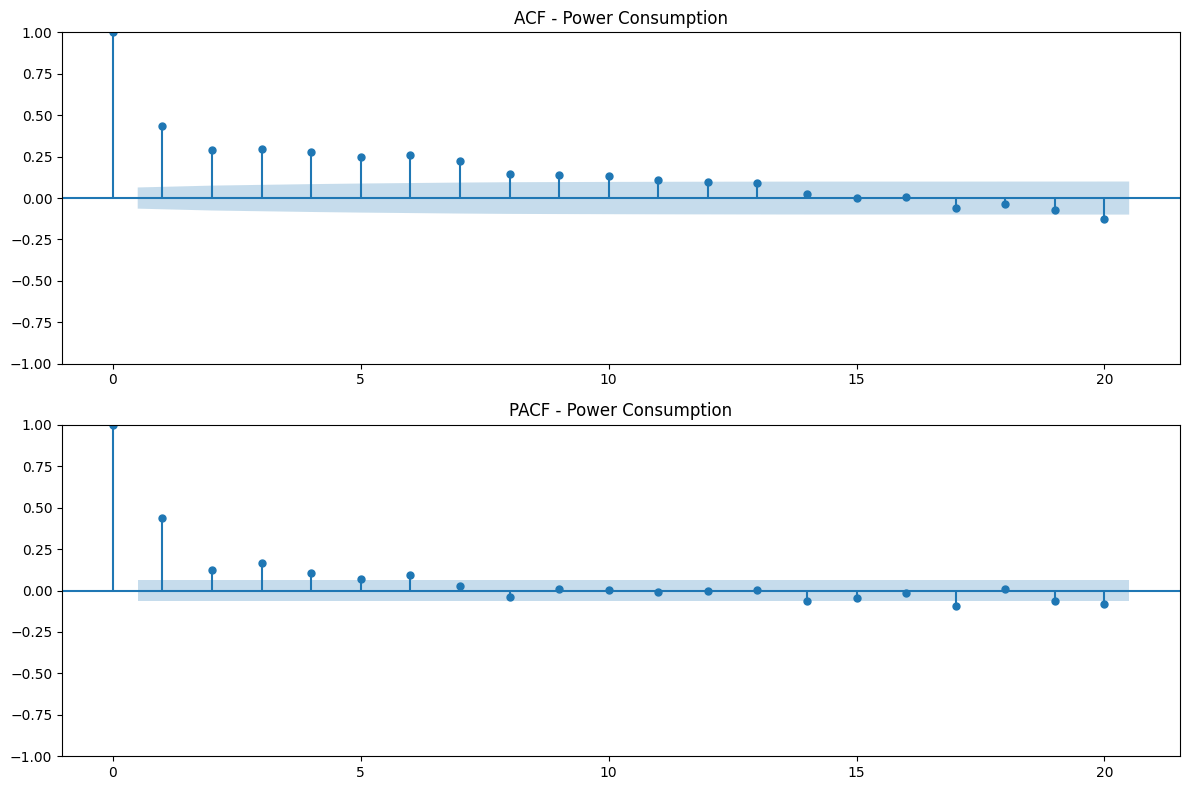

In [ ]:
# THIS PART IS FROM CHATGPT IDK WHAT NUMBERS WOULD BE BEST
lag_acf =20
lag_pacf =20
height, width = 4, 12

# plotting pacf for AR and acf for MA
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(width, 2 * height))
plot_acf(daily_avg['WIND'].dropna(), lags=lag_acf, ax=ax[0])
ax[0].set_title('ACF - Power Consumption')
plot_pacf(daily_avg['WIND'].dropna(), lags=lag_pacf, ax=ax[1], method='ols')
ax[1].set_title('PACF - Power Consumption')
plt.tight_layout()
plt.show()

In [ ]:
# Interpreting the ACF and PACF for orders of q and p respectively
# ACF cutoff → 1 (MA order)
# PACF cutoff → 1 (AR order) -- not sure can be 2 as well

# Interpreting the ACF and PACF for orders of q and p respectively
# ACF cutoff → 1 (MA order)
# PACF cutoff → 1 (AR order) -- not sure can be 2 as well
# AR(p) = 1
# MA(q) = 0
# Differencing (d) = 1 (based on stationarity tests)

In [ ]:
#split into train and test sets
train_len = int(0.8 * len(daily_avg))
train = daily_avg['WIND'][:train_len]
test = daily_avg['WIND'][train_len:]

                            AutoReg Model Results                             
Dep. Variable:                   WIND   No. Observations:                  752
Model:                     AutoReg(1)   Log Likelihood               -1893.504
Method:               Conditional MLE   S.D. of innovations              3.011
Date:                Tue, 14 Oct 2025   AIC                           3793.007
Time:                        18:51:07   BIC                           3806.871
Sample:                    01-08-1961   HQIC                          3798.349
                         - 05-25-1975                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.7295      0.344     16.649      0.000       5.055       6.404
WIND.L1        0.4154      0.033     12.508      0.000       0.350       0.480
                                    Roots           

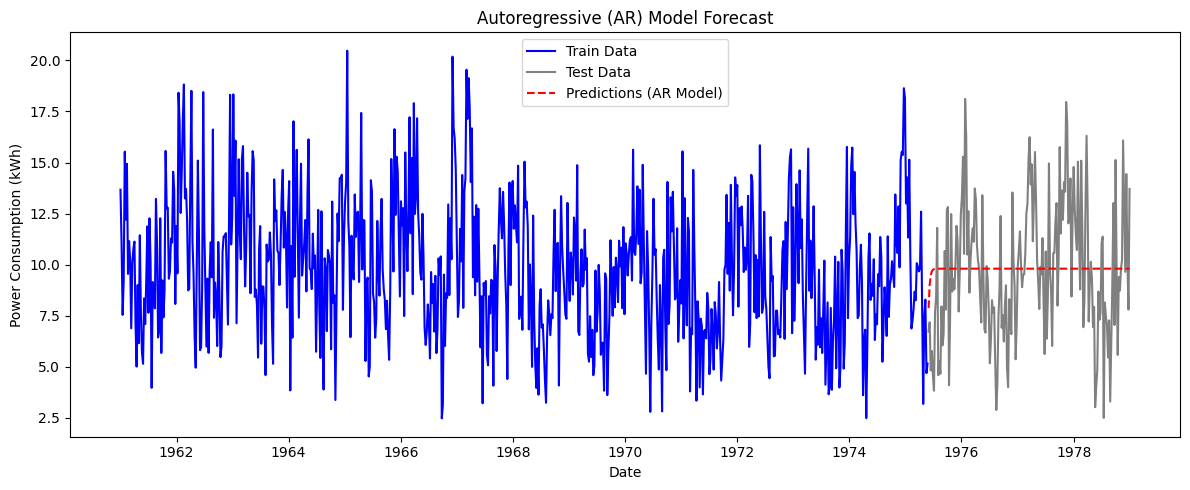

In [ ]:
# AUTOREGRESSION MODEL (AR)
ar_model = AutoReg(train, lags=1).fit()
print(ar_model.summary())

ar_pred = ar_model.predict(start=train_len, end=len(daily_avg)-1, dynamic=False)#predictions

plt.figure(figsize=(12, 5))
sns.lineplot(x=daily_avg.index[:train_len], y=train, label='Train Data', color='blue')
sns.lineplot(x=daily_avg.index[train_len:], y=test, label='Test Data', color='gray')
sns.lineplot(x=daily_avg.index[train_len:], y=ar_pred, label='Predictions (AR Model)', color='red', linestyle='--')
plt.title('Autoregressive (AR) Model Forecast')
plt.xlabel('Date')
plt.ylabel('Power Consumption (kWh)')
plt.legend()
plt.tight_layout()
plt.show()

                               SARIMAX Results                                
Dep. Variable:                   WIND   No. Observations:                  752
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -1913.091
Date:                Tue, 14 Oct 2025   AIC                           3832.182
Time:                        19:08:28   BIC                           3846.050
Sample:                    01-01-1961   HQIC                          3837.525
                         - 05-25-1975                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.8138      0.155     63.140      0.000       9.509      10.118
ma.L1          0.3377      0.034      9.800      0.000       0.270       0.405
sigma2         9.4874      0.517     18.348      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


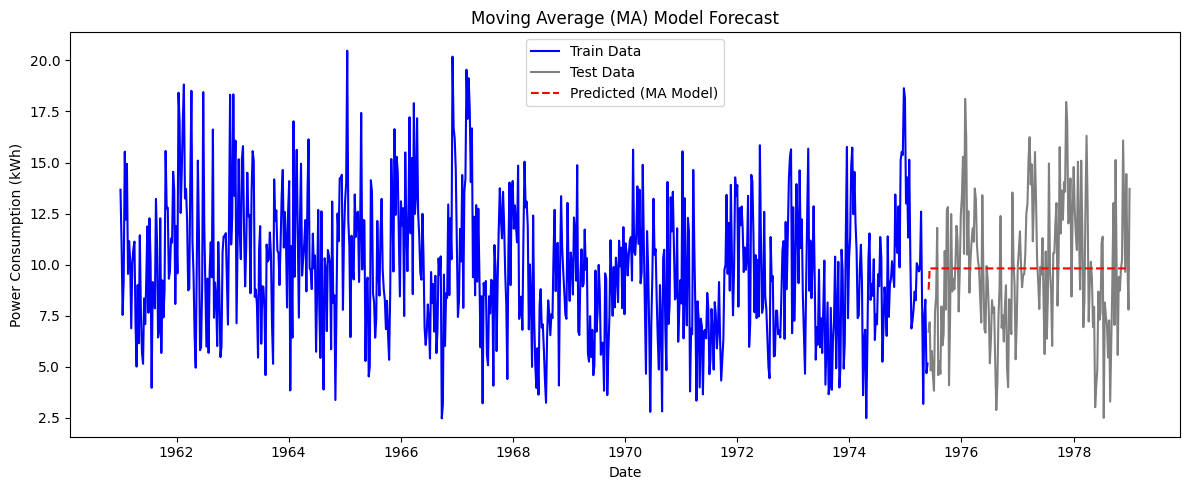

In [ ]:
# MOVING AVERAGE (MA) MODEL
ma_model = ARIMA(train, order=(0, 0, 1)).fit()
print(ma_model.summary())

ma_pred = ma_model.predict(start=train_len, end=len(daily_avg) - 1, typ='levels')

plt.figure(figsize=(12, 5))
sns.lineplot(x=daily_avg.index[:train_len], y=train, label='Train Data', color='blue')
sns.lineplot(x=daily_avg.index[train_len:], y=test, label='Test Data', color='gray')
sns.lineplot(x=daily_avg.index[train_len:], y=ma_pred, label='Predicted (MA Model)', color='red', linestyle='--')
plt.title('Moving Average (MA) Model Forecast')
plt.xlabel('Date')
plt.ylabel('Power Consumption (kWh)')
plt.legend()
plt.tight_layout()
plt.show()

                               SARIMAX Results                                
Dep. Variable:                   WIND   No. Observations:                  752
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -1879.530
Date:                Tue, 14 Oct 2025   AIC                           3767.059
Time:                        19:06:23   BIC                           3785.550
Sample:                    01-01-1961   HQIC                          3774.183
                         - 05-25-1975                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.8017      0.318     30.791      0.000       9.178      10.426
ar.L1          0.8621      0.037     23.249      0.000       0.789       0.935
ma.L1         -0.6009      0.058    -10.384      0.0

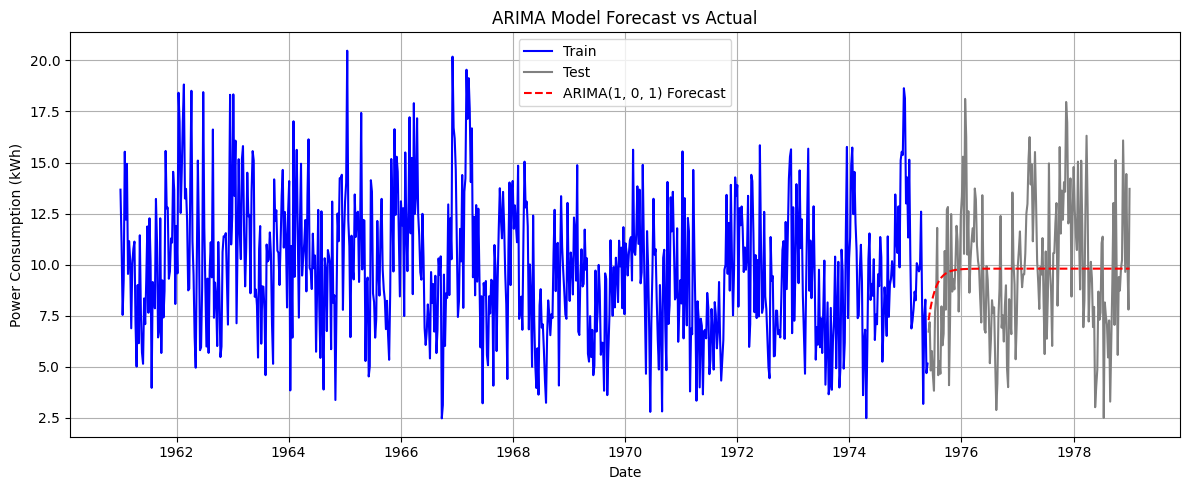

In [ ]:
# ARIMA MODEL

order = (1, 0, 1)
arima_model = ARIMA(train, order=order)
arima_fit = arima_model.fit()

print(arima_fit.summary())
arima_pred = arima_fit.forecast(steps=len(test))

plt.figure(figsize=(12,5))
plt.plot(train, label='Train', color='blue')
plt.plot(test, label='Test', color='gray')
plt.plot(test.index, arima_pred, label=f'ARIMA{order} Forecast', color='red', linestyle='--')
plt.title("ARIMA Model Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Power Consumption (kWh)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#Evaluate all models/look at the mean
arima_rmse = np.sqrt(mean_squared_error(test, arima_pred))
ma_rmse = np.sqrt(mean_squared_error(test, ma_pred))
ar_rmse = np.sqrt(mean_squared_error(test, ar_pred))
print("RMSE Comparison:")
print("ARIMA RMSE:", arima_rmse)
print("MA RMSE:", ma_rmse)
print("AR RMSE:", ar_rmse)

RMSE Comparison:
ARIMA RMSE: 3.2155445036194252
MA RMSE: 3.2843575953617603
AR RMSE: 3.274695778713597


                                     SARIMAX Results                                     
Dep. Variable:                              WIND   No. Observations:                  752
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood               -1873.243
Date:                           Tue, 14 Oct 2025   AIC                           3756.486
Time:                                   19:13:45   BIC                           3779.540
Sample:                               01-01-1961   HQIC                          3765.373
                                    - 05-25-1975                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9967      0.003    340.270      0.000       0.991       1.002
ma.L1         -0.7347      0.025    -28.961

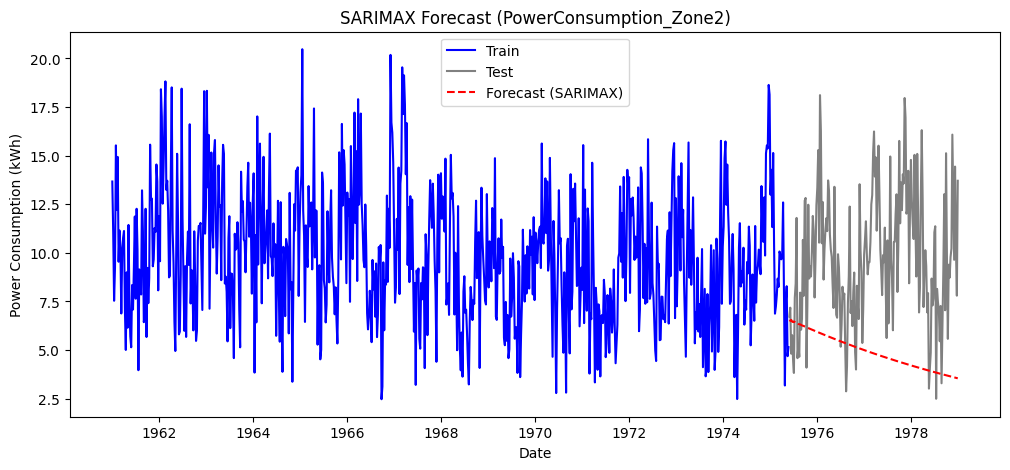

In [ ]:
# THIS IS NOT REQUIRED BUT LOOKED AT THIS AS WELL BC SARIMAX IS BETTER FOR SEASONALLY CHANGING DATA AND ENERGY CONSUMPTIONS IS DEF SEASONAL
# didn't let me import pdarima for some reason (we did it with that in class) so I used SARIMAX function directly embedded instead

train_data = daily_avg['WIND'][:train_len]
test_data = daily_avg['WIND'][train_len:]

#orders
order = (1, 0, 1)#this is from the ARIMA we did above
seasonal_order = (1, 0, 1, 7)# weekly seasonality for daily data (m=7)

#fit model
import statsmodels.api as sm
sarimax_model = sm.tsa.statespace.SARIMAX(train_data,
                                          order=order,
                                          seasonal_order=seasonal_order,
                                          enforce_stationarity=False,
                                          enforce_invertibility=False).fit()

print(sarimax_model.summary())

# forecast test
n_periods = len(test_data)
sarimax_pred = sarimax_model.forecast(steps=n_periods)

# evaluate bc our prev models didn't predict accurately
sarimax_rmse = np.sqrt(mean_squared_error(test_data, sarimax_pred))
print("SARIMAX RMSE:", sarimax_rmse)

#plot
plt.figure(figsize=(12,5))
sns.lineplot(x=train_data.index, y=train_data, label='Train', color='blue')
sns.lineplot(x=test_data.index, y=test_data, label='Test', color='gray')
sns.lineplot(x=test_data.index, y=sarimax_pred, label='Forecast (SARIMAX)', color='red', linestyle='--')
plt.title('SARIMAX Forecast (PowerConsumption_Zone2)')
plt.xlabel('Date')
plt.ylabel('Power Consumption (kWh)')
plt.legend()
plt.show()
